Tujuan dari a/b testing ini adalah untuk melihat apakah memberikan kata-kata empatik (Varian) di kotak teks (placeholder) akan memancing pengguna menulis curhatan lebih panjang dibandingkan kotak teks kosong biasa (Origin). Metrik yang diukur adalah karakter teks dari kolom MOOD_NOTE.

Hipotesis Nol ($H_0$): Tidak ada perbedaan rata-rata panjang karakter antara tampilan lama dan tampilan baru.

Hipotesis Alternatif ($H_1$): Ada perbedaan rata-rata panjang karakter yang signifikan antara kedua tampilan.

Metrik Penentu: taraf signifikansi alpha ($0.05$)

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats

df = pd.read_csv('moodjar_ab_test.csv')

df['note_length'] = df['MOOD_NOTE'].str.len()

# Memisahkan data berdasarkan kelompok A/B Testing
origin_data = df[df['user_type'] == 'origin']['note_length']
varian_data = df[df['user_type'] == 'varian']['note_length']

print(f"Jumlah User Origin: {len(origin_data)}, Rata-rata panjang teks: {origin_data.mean():.2f} karakter")
print(f"Jumlah User Varian: {len(varian_data)}, Rata-rata panjang teks: {varian_data.mean():.2f} karakter")

Jumlah User Origin: 7514, Rata-rata panjang teks: 118.07 karakter
Jumlah User Varian: 7345, Rata-rata panjang teks: 176.40 karakter


Karena kita membandingkan rata-rata (panjang karakter) dari dua kelompok pengguna yang berbeda, uji statistik yang tepat adalah Independent Two-Sample T-Test.

In [ ]:
# tingkat signifikansi (alpha)
alpha = 0.05

# Melakukan Independent T-Test (asumsi varians tidak sama)
t_statistic, p_value = stats.ttest_ind(origin_data, varian_data, equal_var=False)

print(f"Nilai T-Statistic: {t_statistic:.4f}")
print(f"Nilai P-Value: {p_value:.10f}")

print("-" * 30)
if p_value < alpha:
    print(f"H0 DITOLAK (p-value < {alpha}).")
    print("Kesimpulan: Ada perbedaan yang signifikan secara statistik antara rata-rata panjang teks curhatan pengguna di kelompok Origin dan Varian.")
    print("Rekomendasi: Fitur teks placeholder pada Varian terbukti berhasil memancing pengguna menulis curhatan lebih panjang dan layak dirilis ke seluruh pengguna.")
else:
    print(f"H0 GAGAL DITOLAK (p-value >= {alpha}).")
    print("Kesimpulan: Tidak ada perbedaan signifikan antara kedua kelompok.")
    print("Rekomendasi: Perubahan desain tidak memberikan dampak berarti. Pertimbangkan iterasi desain lain.")

Nilai T-Statistic: -56.8530
Nilai P-Value: 0.0000000000
------------------------------
H0 DITOLAK (p-value < 0.05).
Kesimpulan: Ada perbedaan yang signifikan secara statistik antara rata-rata panjang teks curhatan pengguna di kelompok Origin dan Varian.
Rekomendasi: Fitur teks placeholder pada Varian terbukti berhasil memancing pengguna menulis curhatan lebih panjang dan layak dirilis ke seluruh pengguna.


Hasil perhitungan menunjukkan p-value bernilai 0.0 (mendekati nol). Karena p-value jauh lebih kecil dari alpha (0.05), maka Hipotesis Nol (H0) ditolak. Hal ini menunjukkan bahwa perbedaan rata-rata panjang teks antara kedua kelompok sangat signifikan secara statistik

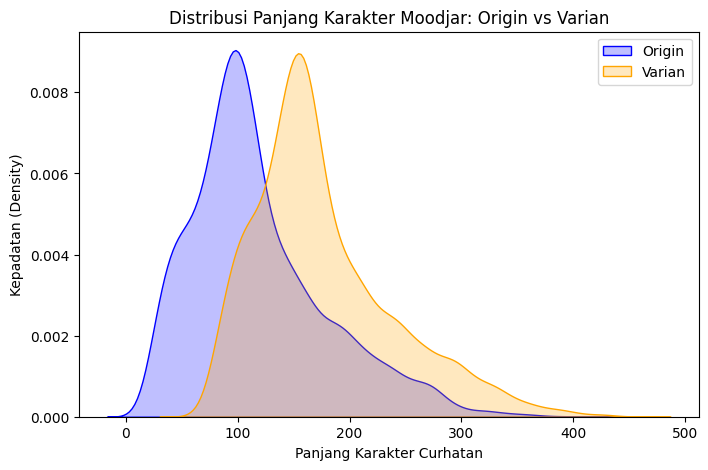

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.kdeplot(origin_data, label='Origin', fill=True, color='blue')
sns.kdeplot(varian_data, label='Varian', fill=True, color='orange')

plt.title('Distribusi Panjang Karakter Moodjar: Origin vs Varian')
plt.xlabel('Panjang Karakter Curhatan')
plt.ylabel('Kepadatan (Density)')
plt.legend()
plt.show()